#### LangChain vs LangGraph (feat. LangGraph 개념 설명)
* LangGraph의 개념과 주요 기능을 이해하고, 차이점을 비교합니다.

#### LangChain vs LangGraph 한눈에 비교

| 구분 | LangChain (LCEL) | LangGraph |
|---|---|---|
| 핵심 개념 | 체인(Chain): 프롬프트 → 모델 → 파서를 파이프 연산자로 연결 | 그래프(Graph): 노드(Node)와 엣지(Edge)로 구성한 상태 기계 |
| 실행 흐름 | 한 방향 순차/병렬 실행 | 조건 분기, 반복(루프), 재시도 가능 |
| 상태 관리 | 단계 간 입출력을 직접 전달 (공유 상태 없음) | 공유 `State`를 노드가 읽고 갱신 (리듀서로 병합) |
| 지속성 | 없음 | 체크포인터(Checkpointer)로 상태 저장·복원, 중단 후 재개 |
| 사람 개입 | 직접 구현 | human-in-the-loop(`interrupt`) 지원 |
| 적합한 용도 | 단순 파이프라인, RAG 체인, 한 번에 끝나는 작업 | 에이전트, 다단계 협업, 분기·반복이 있는 워크플로우 |

> LangGraph는 LangChain의 대체재가 아니라 **그 위에 올라가는 계층**입니다. LangGraph의 노드 안에서 LangChain의 모델·프롬프트·도구를 그대로 사용하며, LangChain 1.x의 `create_agent`도 내부적으로 LangGraph 위에서 동작합니다.
> 선형 흐름은 LangChain이 더 간단하고, 분기·루프·상태 유지가 필요해질 때 LangGraph가 유리합니다.

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
UPSTAGE_API_KEY = os.getenv("UPSTAGE_API_KEY")


In [2]:
from langchain_openai import ChatOpenAI
from langchain_upstage import ChatUpstage

# 사용할 LLM 제공자 선택: "upstage" 또는 "openai" — 이 값만 바꾸면 이후 모든 셀의 모델이 바뀜
PROVIDER = "upstage"

# 제공자별 설정 (cls: 사용할 LangChain 채팅 모델 클래스)
LLM_CONFIGS = {
    "upstage": {
        "cls": ChatUpstage,
        "api_key": UPSTAGE_API_KEY,
        "base_url": "https://api.upstage.ai/v1",
        "model": "solar-pro3",
    },
    "openai": {
        "cls": ChatOpenAI,
        "api_key": OPENAI_API_KEY,
        "base_url": None,  # 생략 시 OpenAI 기본 엔드포인트 사용
        "model": "gpt-4o-mini",  # 테스트에는 작은 모델 사용 (대안: "gpt-4o")
    },
}
MAX_RETRIES = 5  # 503 등 일시 장애 자동 재시도 횟수


def get_llm(temperature: float = 0.5, provider: str | None = None, verbose: bool = True, **kwargs):
    """선택한 제공자(기본값: PROVIDER)의 채팅 모델 인스턴스를 생성합니다.
    verbose=True 이면 생성된 모델 정보를 출력합니다.
    kwargs: 모델 클래스에 그대로 전달할 추가 옵션 (예: seed=42, timeout=60)"""
    provider = provider or PROVIDER
    if provider not in LLM_CONFIGS:
        raise ValueError(f"지원하지 않는 제공자: {provider} (사용 가능: {list(LLM_CONFIGS)})")
    config = dict(LLM_CONFIGS[provider])
    model_cls = config.pop("cls")
    if not config["api_key"]:
        raise RuntimeError(f".env 파일에 {provider.upper()}_API_KEY 가 없습니다.")
    llm = model_cls(**config, temperature=temperature, max_retries=MAX_RETRIES, **kwargs)
    if verbose:
        # 생성된 모델 정보 출력 (API 키는 출력하지 않음)
        print(f"[LLM 생성] provider={provider} | model={llm.model_name}")
    return llm

c:\myclass\ai_langchain\mylangchin-uv-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# 모델 생성 — 제공자 전환은 위 PROVIDER 값 또는 get_llm(provider="openai") 로 가능
llm = get_llm(temperature=0.5, provider="upstage")


[LLM 생성] provider=upstage | model=solar-pro3


#### LangChain을 사용하여 LLM 호출

In [ ]:
query = 'LangGraph는 무엇인가요?'
ai_msg = llm.invoke(query)
print(ai_msg.content)

#### LangGraph의 기본개념
* `state`는 LangGraph 에이전트의 state를 나타내는 데이터 구조입니다.
* `state`는 `TypedDict`를 사용하여 정의되며, 이는 Python의 타입 힌팅을 통해 구조를 명확히 합니다.
    * 간단하게 `messages`라는 필드만 있습니다.
    * 필요에 따라 다양한 값들을 활용할 수 있습니다.
* `state`는 에이전트의 동작을 결정하는 데 사용되며, 각 노드에서 state를 업데이트하거나 참조할 수 있습니다.
* `state`는 LangGraph의 노드 간에 전달되며, 에이전트의 state 전이를 관리합니다.

In [15]:
from typing import Annotated # 타입 힌트를 사용하기 위해 
from typing_extensions import TypedDict # 구조화된 딕셔너리 타입을 정의하기 위해 

from langgraph.graph.message import add_messages 
from langchain_core.messages import AnyMessage # LangChain에서 사용하는 모든 종류의 메시지(예: HumanMessage, AIMessage, ToolMessage)

# AgentState는 에이전트의 현재 상태를 나타내는 딕셔너리 타입을 정의합니다.
# TypedDict를 사용하면 딕셔너리가 어떤 키와 값 타입을 가져야 하는지 명확하게 지정할 수 있습니다.
class AgentState(TypedDict):
    # 'messages' 키는 에이전트의 대화 기록을 저장합니다.
    # 이 목록에는 LangChain 메시지 객체(AnyMessage)가 들어갑니다.
    # Annotated[list[...], add_messages]: 리듀서(reducer)는 "리스트 전체"에 붙여야 합니다.
    # 노드가 {'messages': [새 메시지]}를 반환하면 기존 목록을 덮어쓰지 않고 끝에 추가(append)합니다.
    # (주의: list[Annotated[AnyMessage, add_messages]] 처럼 원소에 붙이면 리듀서가 동작하지 않아
    #  새 값이 기존 메시지를 덮어씁니다.)
    messages: Annotated[list[AnyMessage], add_messages]

- 위에 선언한 `AgentState`를 활용하여 `StateGraph`를 생성합니다.

In [16]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)
print(type(graph_builder))

<class 'langgraph.graph.state.StateGraph'>


- `graph`에 추가할 `node`를 생성합니다
-  `node`는 LangGraph에서 실행되는 개별적인 작업 단위를 의미합니다. 
    - 각 노드는 특정 기능을 수행하는 독립적인 컴포넌트로, 예를 들어 텍스트 생성, 데이터 처리, 또는 의사 결정과 같은 작업을 담당할 수 있습니다.
    - `node`는 기본적으로 함수(function)로 정의되고, 뒤에서 다루지만 다른 에이전트(agent)를 활용할 수도 있습니다

In [17]:
# Node 역할을 하는 함수의 인자로 state 객체를 사용함  LLM을 호출하는 노드
def generate(state: AgentState) -> AgentState:
    """
    `generate` 노드는 사용자의 질문을 받아서 응답을 생성하는 노드입니다.
    """
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

- `node`를 생성한 후에 `edge`로 연결합니다
- `edge`는 노드들 사이의 연결을 나타내며, 데이터와 제어 흐름의 경로를 정의합니다. 
    - 엣지를 통해 한 노드의 출력이 다음 노드의 입력으로 전달되어, 전체적인 워크플로우가 형성됩니다.
    - `node`와 `edge`의 조합은 방향성 그래프(Directed Graph)를 형성하며, 이를 통해 복잡한 AI 에이전트의 행동 흐름을 구조화할 수 있습니다

In [18]:
# LLM을 호출하는 generate 함수를 Node로 추가함
graph_builder.add_node('generate', generate)

- 모든 그래프는 `START(시작)`와 `END(종료)`가 있습니다
    - `END`를 explicit하게 선언하지 않는 경우도 종종 있지만, 가독성을 위해 작성해주는 것을 권장합니다

In [19]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

- `node`를 생성하고 `edge`로 연결한 후에 `compile` 메서드를 호출하여 `Graph`를 생성합니다

In [20]:
graph = graph_builder.compile()
print(type(graph))

<class 'langgraph.graph.state.CompiledStateGraph'>


- `compile` 후에는 그래프를 시각화하여 확인할 수 있습니다
- 의도한대로 그래프가 생성됐는지 확인하는 습관을 기르는 것이 좋습니다
    - `git`에서 코드 작업물을 commit하기 전에 `git diff`를 통해 변경사항을 확인하는 것과 같습니다

In [21]:
# 그래프 시각화 (Mermaid 코드 출력)
mermaid_code = graph.get_graph().draw_mermaid()
print("Mermaid Code:")
print(mermaid_code)

Mermaid Code:
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	generate(generate)
	__end__([<p>__end__</p>]):::last
	__start__ --> generate;
	generate --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



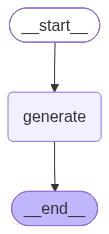

In [22]:
# 이미지로 보려면 display(Image(graph.get_graph().draw_mermaid_png())) 를 사용합니다.

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

* https://mermaid.live/ 에서  mermaid_code 로 직접 확인해도 됩니다. 

* [Graph 이미지](https://mermaidchart.com/play?utm_source=mermaid_live_editor&utm_medium=share#pako:eNpVkN1ugjAUx1-lObvRBLCAVq3Gm_kIu9q6mAqn0AwKKSWZM777KirR3vR8_f7n4wxZkyNwKKxsS_Kx3wgj3OHQOWn9N_natrvR287a3feUc6607dy1sECDVjqcPIzpDUeTj_Bgj2glb-QoSsJwRx745ll0yNz5IZF5uNujIjkq2VeOKF1V_E0liioVVNpgWKIuSsfjKHkBhoGH8rBpZabdidOXgutYd7mjOjKVQeBPonPgzvYYQI22llcXzsIQIsCVWKMA7s1c2h8Bwlw800rz2TT1A7NNX5TAlaw67_Vt7tfaa-mPXY9R6xdE-970xgFP4kED-Bl-gaeURYyyNEmXbJGuaDIP4OTDLIqT-XoVp2tK54ytLwH8DV1ptFou6NOLL_-94J8W) 

In [28]:
from langchain_core.messages import HumanMessage

query = 'LangGraph는 무엇인가요? LangChain과의 차이점은 무엇인가요?'
initial_state = {'messages': [HumanMessage(query)]}
result = graph.invoke(initial_state)

print(type(result))
print(type(result["messages"]),type(result['messages'][0]), type(result['messages'][1]))

for msg in result["messages"]:
    msg.pretty_print()

<class 'dict'>
<class 'list'> <class 'langchain_core.messages.human.HumanMessage'> <class 'langchain_core.messages.ai.AIMessage'>
================================ Human Message =================================

LangGraph는 무엇인가요? LangChain과의 차이점은 무엇인가요?
================================== Ai Message ==================================

## LangGraph란?  

**LangGraph**는 **LangChain** 위에 구축된 **그래프‑기반(state‑machine) 프레임워크**입니다.  
- **핵심 아이디어**: LLM 에이전트가 “노드(함수·툴) → 엣지(데이터 흐름) → 상태(state)” 로 구성된 **방향성 그래프**를 따라 실행되도록 설계합니다.  
- **주요 특징**  

| 특징 | 설명 |
|------|------|
| **노드 기반** | 각 노드는 하나의 **스텝**(예: LLM 호출, 툴 실행, 데이터 변환)이며, `run_node(node_id, state)` 형태로 구현됩니다. |
| **엣지(Transition)** | 현재 상태에 따라 **다음 노드**를 동적으로 선택합니다. `next_node(state)` 혹은 `next_node(state, inputs)` 로 정의합니다. |
| **상태 관리** | `state` 객체는 그래프 전체를 관통하는 **전역 컨텍스트**이며, 노드 간 데이터를 자유롭게 공유할 수 있습니다. |
| **루프 & 반복** | `while`, `for`, `repeat_until` 같은 **루프 노드**를 그래프에 삽입해 반복적인 작업을 손쉽게 구현합니다. |
| **동시성** | 여러 엣지를 동시에 탐색하거나, **멀티‑에이전트**

In [29]:
# 최종 AI 응답의 텍스트만 출력
print(result['messages'][-1].content)

## LangGraph란?  

**LangGraph**는 **LangChain** 위에 구축된 **그래프‑기반(state‑machine) 프레임워크**입니다.  
- **핵심 아이디어**: LLM 에이전트가 “노드(함수·툴) → 엣지(데이터 흐름) → 상태(state)” 로 구성된 **방향성 그래프**를 따라 실행되도록 설계합니다.  
- **주요 특징**  

| 특징 | 설명 |
|------|------|
| **노드 기반** | 각 노드는 하나의 **스텝**(예: LLM 호출, 툴 실행, 데이터 변환)이며, `run_node(node_id, state)` 형태로 구현됩니다. |
| **엣지(Transition)** | 현재 상태에 따라 **다음 노드**를 동적으로 선택합니다. `next_node(state)` 혹은 `next_node(state, inputs)` 로 정의합니다. |
| **상태 관리** | `state` 객체는 그래프 전체를 관통하는 **전역 컨텍스트**이며, 노드 간 데이터를 자유롭게 공유할 수 있습니다. |
| **루프 & 반복** | `while`, `for`, `repeat_until` 같은 **루프 노드**를 그래프에 삽입해 반복적인 작업을 손쉽게 구현합니다. |
| **동시성** | 여러 엣지를 동시에 탐색하거나, **멀티‑에이전트** 시스템을 하나의 그래프에 배치해 병렬·동시 실행을 지원합니다. |
| **시각화 & 디버깅** | 그래프 구조를 JSON/YAML 로 내보내고, `graphviz` 혹은 LangGraph 자체 UI 로 **시각화**할 수 있어 흐름을 직관적으로 파악합니다. |
| **툴·메모리 통합** | 기존 LangChain 툴, 메모리, 프롬프트 템플릿, 벡터스토어 등을 그대로 **노드** 혹은 **엣지**에 연결해서 사용할 수 있습니다. |
| **배포** | `GraphRunner` 로 그래프를 **단일 함수** 혹은 **FastAPI/Streamlit** 엔드포인트에 쉽게 배포합니다. |

> **

#### 2개의 AI 에이전트 협력하기
* 첫번째 AI 에이전트
    * 사용자의 질문을 분석하고 핵심 키워드와 배경 정보를 추가하는 역할
* 두번째 AI 에이전트
    * 첫번째 에이전트가 제공한 정보를 기반으로 좀 더 자세한 답변을 생성하는 역할    

In [30]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from pprint import pprint


class WorkflowState(TypedDict):
    """2-에이전트 워크플로우의 공유 상태. 각 노드는 자신이 갱신할 키만 반환한다."""
    query: str            # 사용자 원본 질문
    refined_query: str    # agent_1이 정리한 질문
    keywords: str         # 핵심 키워드 (텍스트)
    background_info: str  # 배경 정보 (텍스트)
    final_answer: str     # agent_2의 최종 답변


# 첫번째 AI 에이전트
def agent_1(state: WorkflowState) -> dict:
    """사용자의 질문을 분석하고 핵심 키워드와 배경 정보를 추가하는 역할"""
    query = state['query']

    # llm.invoke()는 AIMessage를 반환하므로 .content 로 텍스트만 꺼내서 사용한다.
    # (객체를 f-string에 그대로 넣으면 content='...' 같은 repr 문자열이 프롬프트에 섞인다)
    keywords = llm.invoke(
        f'질문: {query}\n이 질문에서 핵심 키워드를 3~5개 추출해 주세요. 키워드만 쉼표로 구분해 출력하세요.'
    ).content

    # 질문과 관련된 배경 정보 제공
    background_info = llm.invoke(
        f"질문: {query}\n이 질문을 이해하는 데 도움이 될 만한 추가 정보를 제공해 주세요."
    ).content

    print(f"\n[Agent 1] 원본 질문: {query}")
    print(f"[Agent 1] 핵심 키워드: {keywords}")
    print(f"[Agent 1] 배경 정보: {background_info}\n")

    return {"refined_query": query, "keywords": keywords, "background_info": background_info}

In [31]:
# 두번째 AI 에이전트
def agent_2(state: WorkflowState) -> dict:
    """첫번째 에이전트가 제공한 정보를 기반으로 좀 더 자세한 답변을 생성하는 역할"""
    refined_query = state['refined_query']
    keywords = state['keywords']
    background_info = state['background_info']

    # Agent 1이 제공한 정보를 활용하여 최종 답변 생성
    final_response = llm.invoke(
        f"질문: {refined_query}\n"
        f"핵심 키워드: {keywords}\n"
        f"배경 정보: {background_info}\n"
        f"위 정보를 바탕으로 질문에 대한 깊이 있는 답변을 작성해 주세요."
    )

    print("[Agent 2] 최종 답변 생성 완료\n")

    return {"final_answer": final_response.content}

In [32]:
# WorkFlow 역할을 하는 StateGraph 객체를 생성하기 (상태 구조는 WorkflowState로 명시)
workflow = StateGraph(WorkflowState)

print(type(workflow))
print(workflow.schemas)

<class 'langgraph.graph.state.StateGraph'>
{<class '__main__.WorkflowState'>: {'query': <langgraph.channels.last_value.LastValue object at 0x0000021802025380>, 'refined_query': <langgraph.channels.last_value.LastValue object at 0x0000021802027840>, 'keywords': <langgraph.channels.last_value.LastValue object at 0x0000021802025900>, 'background_info': <langgraph.channels.last_value.LastValue object at 0x0000021802026000>, 'final_answer': <langgraph.channels.last_value.LastValue object at 0x0000021802025D00>}}


In [33]:
# WorkFlow에 Node 추가하기
workflow.add_node("agent_1", agent_1)
workflow.add_node("agent_2", agent_2)

workflow.nodes

{'agent_1': StateNodeSpec(runnable=agent_1(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.WorkflowState'>, retry_policy=None, cache_policy=None, ends=(), defer=False),
 'agent_2': StateNodeSpec(runnable=agent_2(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.WorkflowState'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}

In [34]:
# WorkFlow에 Edge 추가하기
# START -> agent_1 -> agent_2 -> END
workflow.add_edge(START, "agent_1")
workflow.add_edge("agent_1", "agent_2")
workflow.add_edge("agent_2", END)

print(workflow.edges)

{('__start__', 'agent_1'), ('agent_1', 'agent_2'), ('agent_2', '__end__')}


In [36]:
graph = workflow.compile()

print(type(graph))

<class 'langgraph.graph.state.CompiledStateGraph'>


In [37]:
mermaid_code = graph.get_graph().draw_mermaid()
print(mermaid_code)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	agent_1(agent_1)
	agent_2(agent_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> agent_1;
	agent_1 --> agent_2;
	agent_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



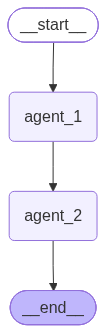

In [38]:

from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Graph 호출하기
query = "LangGraph는 무엇이며, LangChain과 어떤 차이점이 있나요? 그리고 LangGraph를 사용해야 하는 이유는 무엇인가요?"

state = {"query": query}
result = graph.invoke(state)
print(result)

In [ ]:
pprint(result['final_answer'])

#### 같은 작업을 LangChain(LCEL)으로 구현하기
* 위 2-에이전트 작업(키워드 추출 + 배경 정보 → 최종 답변)을 **체인 하나**로 구현합니다.
* 키워드 추출과 배경 정보 생성은 서로 독립적이므로 `RunnableParallel`로 **병렬 실행**됩니다. (LangGraph 버전은 순차 호출)
* 선형 흐름이라 상태 정의나 그래프 구성 없이 짧게 끝납니다.

In [ ]:
from operator import itemgetter

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableParallel

# 각 단계의 프롬프트 (LangGraph 버전의 agent_1, agent_2와 같은 지시문)
keyword_prompt = ChatPromptTemplate.from_template(
    "질문: {query}\n이 질문에서 핵심 키워드를 3~5개 추출해 주세요. 키워드만 쉼표로 구분해 출력하세요."
)
background_prompt = ChatPromptTemplate.from_template(
    "질문: {query}\n이 질문을 이해하는 데 도움이 될 만한 추가 정보를 제공해 주세요."
)
answer_prompt = ChatPromptTemplate.from_template(
    "질문: {query}\n핵심 키워드: {keywords}\n배경 정보: {background_info}\n"
    "위 정보를 바탕으로 질문에 대한 깊이 있는 답변을 작성해 주세요."
)

# 키워드/배경 정보를 병렬로 만든 뒤 → 최종 답변 프롬프트 → 모델 → 문자열
analysis = RunnableParallel(
    query=itemgetter("query"),
    keywords=keyword_prompt | llm | StrOutputParser(),
    background_info=background_prompt | llm | StrOutputParser(),
)
lcel_chain = analysis | answer_prompt | llm | StrOutputParser()

print(f"질문: {query}")
lcel_answer = lcel_chain.invoke({"query": query})
print(type(lcel_answer))
pprint(lcel_answer)

#### LangGraph만의 기능: 조건부 엣지(Conditional Edge)와 재시도 루프
* `agent_2`의 답변이 너무 짧으면 `agent_1`로 되돌아가 다시 만드는 **루프**를 구성합니다.
* 체인(LCEL)은 한 방향 흐름이라 이런 "결과를 보고 되돌아가기"를 표현하기 어렵고, LangGraph에서는 `add_conditional_edges`로 간단히 표현합니다.
* 무한 루프를 막기 위해 상태에 `retry_count`를 두고 `MAX_RETRY`로 제한합니다.

**`add_conditional_edges(출발 노드, 라우팅 함수, 매핑)` 핵심**
* **라우팅 함수**: 상태를 읽고 다음 경로를 나타내는 값을 반환합니다. 상태를 바꾸지는 않습니다.
* **매핑 `{반환값: 이동할 노드}`**: 키는 라우팅 함수의 반환값, 값은 실제로 이동할 노드입니다. `END`는 종료입니다.
  * `{"agent_1": "agent_1", END: END}` → 함수가 `"agent_1"`을 반환하면 재시도, `END`를 반환하면 종료합니다. 키와 값이 같은 경우입니다.
  * `{"retry": "agent_1", "done": END}` → 함수는 조건을 만족하면 `"retry"`, 아니면 `"done"`을 반환해야 합니다. 매핑에 없는 값을 반환하면 오류가 납니다.
* 매핑은 생략할 수 있으나, 적어 두면 시각화(`draw_mermaid`)에 경로가 정확히 그려집니다.

In [46]:
from typing import Literal

MIN_ANSWER_LENGTH = 300  # 이 글자 수보다 짧으면 재시도
MAX_RETRY = 2            # 최대 재시도 횟수 (무한 루프 방지)


class RetryState(WorkflowState):
    """WorkflowState에 재시도 횟수를 추가한 상태"""
    retry_count: int


def agent_2_counted(state: RetryState) -> dict:
    """agent_2를 실행하고 시도 횟수를 1 증가시킨다."""
    result = agent_2(state)
    result["retry_count"] = state.get("retry_count", 0) + 1
    return result


def route_after_agent_2(state: RetryState) -> Literal["agent_1", "__end__"]:
    """답변이 짧고 재시도 여유가 있으면 agent_1로, 아니면 종료한다."""
    too_short = len(state["final_answer"]) < MIN_ANSWER_LENGTH
    if too_short and state["retry_count"] <= MAX_RETRY:
        print(f"[Router] 답변이 {len(state['final_answer'])}자로 짧음 -> agent_1 재시도 ({state['retry_count']}회째)")
        return "agent_1"
    return END


retry_workflow = StateGraph(RetryState)
retry_workflow.add_node("agent_1", agent_1)
retry_workflow.add_node("agent_2", agent_2_counted)
retry_workflow.add_edge(START, "agent_1")
retry_workflow.add_edge("agent_1", "agent_2")
# agent_2 실행 후 route_after_agent_2의 반환값에 따라 다음 노드를 결정
retry_workflow.add_conditional_edges("agent_2", route_after_agent_2, {"agent_1": "agent_1", END: END})

retry_graph = retry_workflow.compile()


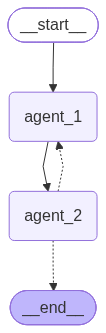

In [47]:
from IPython.display import display, Image

display(Image(retry_graph.get_graph().draw_mermaid_png()))

In [48]:
# 실행 (LLM 호출이 여러 번 발생할 수 있음)
retry_result = retry_graph.invoke({"query": query, "retry_count": 0})
print("총 시도 횟수:", retry_result["retry_count"])
pprint(retry_result["final_answer"])


[Agent 1] 원본 질문: LangGraph는 무엇이며, LangChain과 어떤 차이점이 있나요? 그리고 LangGraph를 사용해야 하는 이유는 무엇인가요?
[Agent 1] 핵심 키워드: LangGraph, LangChain, 차이점, 사용 이유, 핵심 키워드
[Agent 1] 배경 정보: Okay, I need to explain what LangGraph is and how it differs from LangChain, and why someone would use LangGraph. Let me start by recalling what I know about both.

LangChain is a framework for developing applications powered by language models. It helps with things like chaining prompts, integrating with external data sources, and building agents that can use tools. It's pretty comprehensive, right? It handles memory, chains, agents, and more.

Now, LangGraph. I remember it's a newer tool, maybe a successor or a different approach. I think it's built on top of LangChain but uses a graph-based structure. Graphs are good for modeling complex workflows with nodes and edges, which might represent different steps or components of an application. So LangGraph probably allows for more flexible and dynamic workflows compared t